1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2: Load Dataset

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


3: Explore Dataset

In [3]:
print(df.shape)

df.info()

df.describe()

print(df.isnull().sum())

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


4: Correlation Heatmap

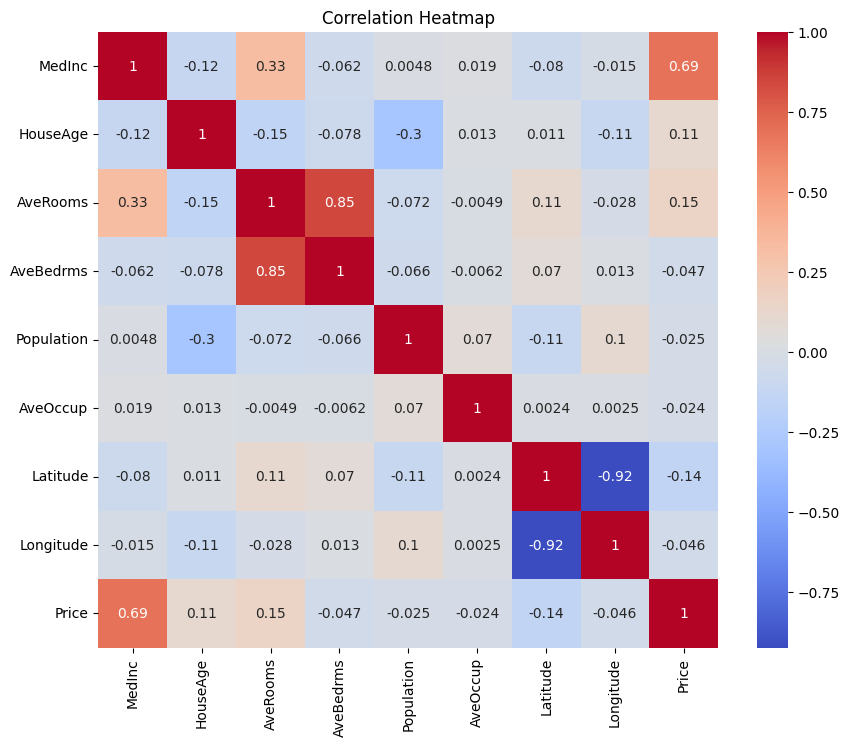

In [4]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

5: Train-Test Split

In [5]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

6: Feature Scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

7: Linear Regression

In [7]:
linear = LinearRegression()

linear.fit(X_train_scaled, y_train)

linear_pred = linear.predict(X_test_scaled)

8: Polynomial Regression

In [8]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)

poly_pred = poly_model.predict(X_test_scaled)

9: Ridge Regression

In [9]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

10: Lasso Regression

In [10]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

11: Evaluation Function

In [11]:
def evaluate_model(name, y_true, pred):

    mae = mean_absolute_error(y_true, pred)
    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred)

    return [name, mae, mse, rmse, r2]

12: Compare Models

In [12]:
results = pd.DataFrame([

    evaluate_model("Linear Regression", y_test, linear_pred),

    evaluate_model("Polynomial Regression", y_test, poly_pred),

    evaluate_model("Ridge Regression", y_test, ridge_pred),

    evaluate_model("Lasso Regression", y_test, lasso_pred)

], columns=["Model","MAE","MSE","RMSE","R2 Score"])

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Polynomial Regression,0.467001,0.464302,0.681397,0.645682
2,Ridge Regression,0.533193,0.555855,0.745557,0.575816
3,Lasso Regression,0.535326,0.548255,0.740442,0.581615


13: Best Model

In [13]:
results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
1,Polynomial Regression,0.467001,0.464302,0.681397,0.645682
3,Lasso Regression,0.535326,0.548255,0.740442,0.581615
2,Ridge Regression,0.533193,0.555855,0.745557,0.575816
0,Linear Regression,0.533200,0.555892,0.745581,0.575788


14: Actual vs Predicted (Linear Regression)

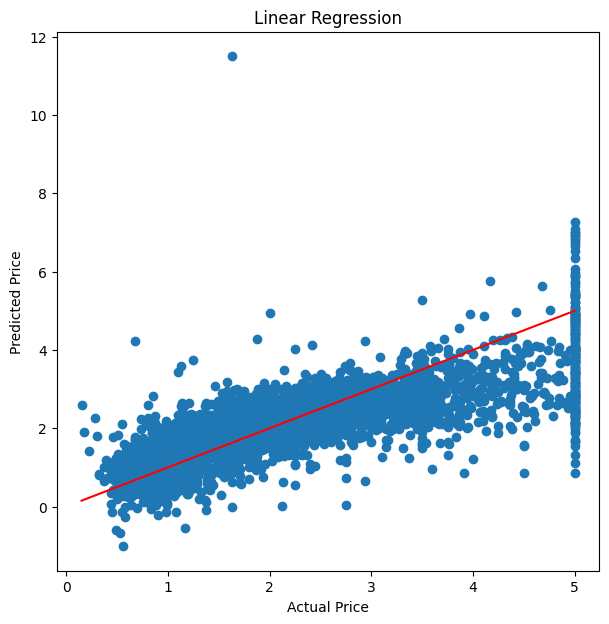

In [14]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, linear_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Linear Regression")

plt.show()

15: Actual vs Predicted (Polynomial)

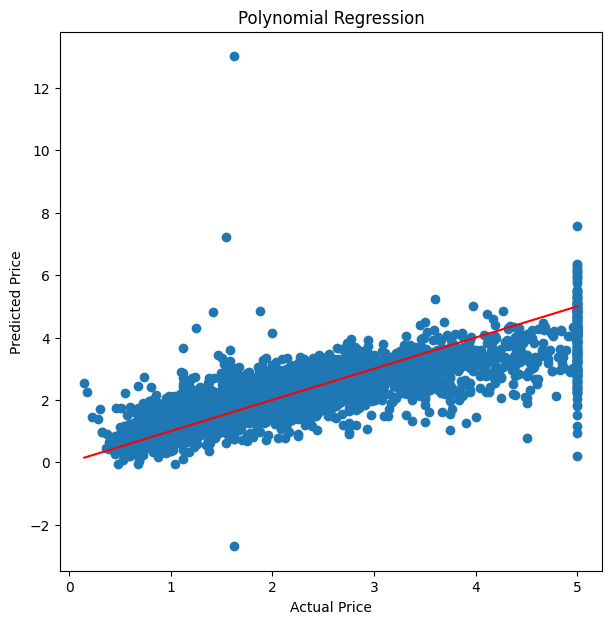

In [15]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, poly_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Polynomial Regression")

plt.show()

16: Actual vs Predicted (Ridge)

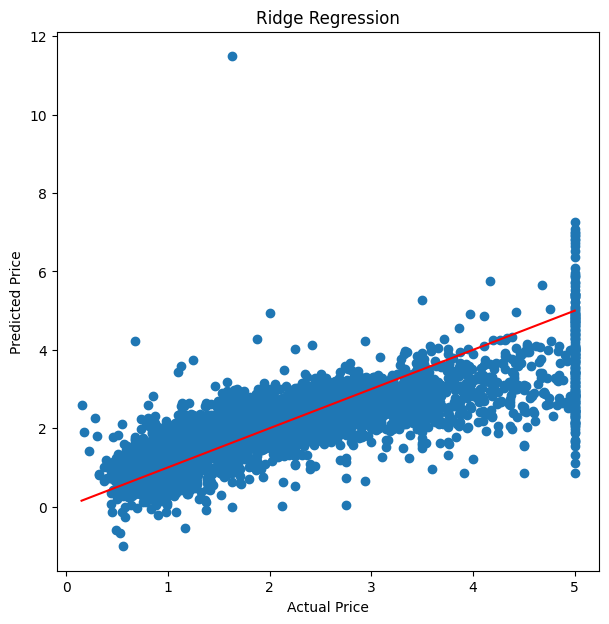

In [16]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, ridge_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Ridge Regression")

plt.show()

17: Actual vs Predicted (Lasso)

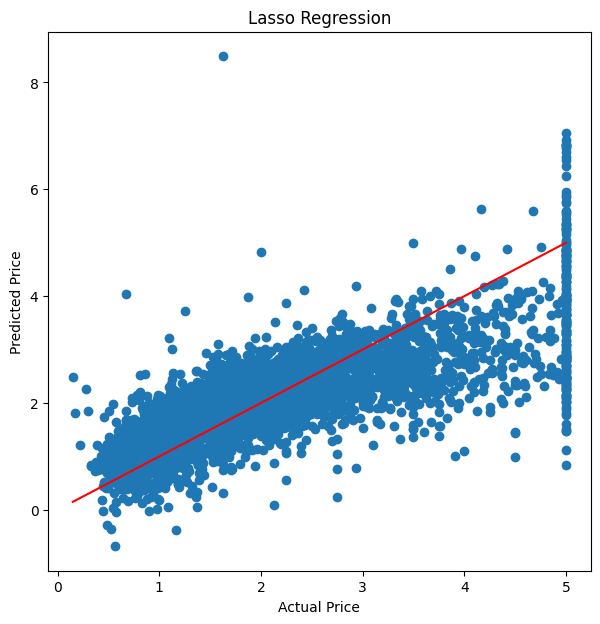

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, lasso_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Lasso Regression")

plt.show()

18: Bar Chart Comparison

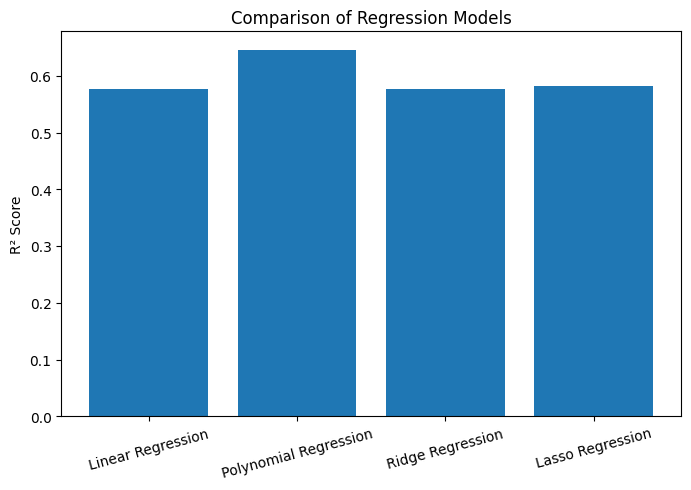

In [18]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.xticks(rotation=15)

plt.title("Comparison of Regression Models")

plt.ylabel("R² Score")

plt.show()